# 1. Load Data 

In [5]:
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# =========================================================
# 0. Set random seed
# =========================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)


In [6]:
# =========================================================
# 1. Basic settings
# =========================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

npz_path = "GAF_ReSplitDatasets.npz"

batch_size = 32
num_epochs = 200
learning_rate = 5e-5
weight_decay = 1e-3
patience = 30

# 只使用前三个加速度通道，因此单独保存模型，避免覆盖原来的 7-channel 结果
save_path = "best_gaf_cnn_vit_mlp_acc3_model.pth"

Using device: cuda


In [ ]:
# =========================================================
# 2. Load npz data
# =========================================================

data = np.load(npz_path)

X_train = data["X_train"]
y_train = data["y_train"]

X_val = data["X_val"]
y_val = data["y_val"]

X_test = data["X_test"]
y_test = data["y_test"]

print("Original X_train shape:", X_train.shape)
print("Original y_train shape:", y_train.shape)
print("Original X_val shape:", X_val.shape)
print("Original y_val shape:", y_val.shape)
print("Original X_test shape:", X_test.shape)
print("Original y_test shape:", y_test.shape)


# =========================================================
# 3. Label processing
# =========================================================
# 如果 y 是 one-hot，例如 shape = (N, num_classes)，转成类别编号
# 如果 y 已经是 (N,)，则不变

if len(y_train.shape) > 1:
    y_train = np.argmax(y_train, axis=1)
    y_val = np.argmax(y_val, axis=1)
    y_test = np.argmax(y_test, axis=1)

y_train = y_train.astype(np.int64)
y_val = y_val.astype(np.int64)
y_test = y_test.astype(np.int64)

num_classes = len(np.unique(y_train))
print("Number of classes:", num_classes)


# =========================================================
# 4. Dataset definition
# =========================================================

class GAFDataset(Dataset):
    def __init__(self, X, y, augment=False, noise_std=0.01, noise_prob=0.7):
        """
        This dataset only uses the first three channels:
        Ch1, Ch2, Ch3, corresponding to ax, ay, az.

        Supported original input formats:
        1. (N, 64, 64, 7)  -> NHWC
        2. (N, 7, 64, 64)  -> NCHW
        3. (N, 64, 7, 64)  -> NHCW

        Output format for PyTorch:
        (3, 64, 64)

        augment:
            Whether to add light Gaussian noise to GAF images.
            Only recommended for the training set.

        noise_std:
            Standard deviation of Gaussian noise.
            Since GAF values are usually in [-1, 1],
            0.005 to 0.02 is usually reasonable.

        noise_prob:
            Probability of adding noise to each sample.
        """

        self.X = X.astype(np.float32)
        self.y = y.astype(np.int64)

        self.augment = augment
        self.noise_std = noise_std
        self.noise_prob = noise_prob

        print("Original X shape in Dataset:", self.X.shape)
        print("Use channels: Ch1-Ch3 only")
        print("Augmentation:", self.augment)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]

        # =================================================
        # Case 1: x = (64, 64, 7)
        # Original format: H, W, C
        # Keep Ch1-Ch3: (64, 64, 3)
        # Convert to PyTorch format: (3, 64, 64)
        # =================================================
        if x.shape == (64, 64, 7):
            x = x[:, :, :3]
            x = np.transpose(x, (2, 0, 1))

        # =================================================
        # Case 2: x = (7, 64, 64)
        # Already in PyTorch format: C, H, W
        # Keep Ch1-Ch3: (3, 64, 64)
        # =================================================
        elif x.shape == (7, 64, 64):
            x = x[:3, :, :]

        # =================================================
        # Case 3: x = (64, 7, 64)
        # Original format: H, C, W
        # Keep Ch1-Ch3: (64, 3, 64)
        # Convert to PyTorch format: (3, 64, 64)
        # =================================================
        elif x.shape == (64, 7, 64):
            x = x[:, :3, :]
            x = np.transpose(x, (1, 0, 2))

        else:
            raise ValueError(f"Unexpected input shape: {x.shape}")

        y = self.y[idx]

        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.long)

        # Only apply light GAF noise augmentation to the training set
        if self.augment:
            x = self.add_light_noise(x)

        return x, y

    def add_light_noise(self, x):
        """
        Add light Gaussian noise to GAF images.

        Input:
            x shape: (3, 64, 64)
        """

        if torch.rand(1).item() < self.noise_prob:
            noise = self.noise_std * torch.randn_like(x)
            x = x + noise

            # GAF values are usually in [-1, 1]
            x = torch.clamp(x, -1.0, 1.0)

        return x


# =========================================================
# 5. Build Dataset and DataLoader
# =========================================================

train_dataset = GAFDataset(
    X_train,
    y_train,
    augment=True,
    noise_std=0.02,
    noise_prob=1.0
)

val_dataset = GAFDataset(
    X_val,
    y_val,
    augment=False
)

test_dataset = GAFDataset(
    X_test,
    y_test,
    augment=False
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)


# =========================================================
# 6. CNN + ViT + MLP Model
# =========================================================

class CNNFeatureExtractor(nn.Module):
    def __init__(self, in_channels=3, out_channels=128):
        super(CNNFeatureExtractor, self).__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            # 64 x 64 -> 32 x 32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            # 32 x 32 -> 16 x 16

            nn.Conv2d(64, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
            # Output: 128 x 16 x 16
        )

    def forward(self, x):
        return self.cnn(x)


class PatchEmbedding(nn.Module):
    def __init__(self, in_channels=128, embed_dim=128, patch_size=4):
        super(PatchEmbedding, self).__init__()

        self.patch_size = patch_size

        self.proj = nn.Conv2d(
            in_channels=in_channels,
            out_channels=embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):
        """
        Input:
            x shape: (B, C, H, W)

        After projection:
            x shape: (B, embed_dim, H/patch_size, W/patch_size)

        After flatten:
            x shape: (B, num_patches, embed_dim)
        """

        x = self.proj(x)
        x = x.flatten(2)
        x = x.transpose(1, 2)

        return x


class GAF_CNN_ViT_MLP(nn.Module):
    def __init__(
        self,
        in_channels=3,
        num_classes=3,
        cnn_out_channels=128,
        embed_dim=128,
        patch_size=4,
        num_heads=4,
        num_transformer_layers=2,
        mlp_hidden_dim=128,
        dropout=0.5
    ):
        super(GAF_CNN_ViT_MLP, self).__init__()

        self.cnn = CNNFeatureExtractor(
            in_channels=in_channels,
            out_channels=cnn_out_channels
        )

        self.patch_embed = PatchEmbedding(
            in_channels=cnn_out_channels,
            embed_dim=embed_dim,
            patch_size=patch_size
        )

        # CNN output size is 16 x 16.
        # With patch_size = 4, number of patches is 4 x 4 = 16.
        num_patches = (16 // patch_size) * (16 // patch_size)

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        self.pos_embedding = nn.Parameter(
            torch.zeros(1, num_patches + 1, embed_dim)
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_transformer_layers
        )

        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, mlp_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden_dim, num_classes)
        )

        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embedding, std=0.02)

    def forward(self, x):
        """
        Input:
            x shape: (B, 3, 64, 64)

        Output:
            out shape: (B, num_classes)
        """

        x = self.cnn(x)

        x = self.patch_embed(x)

        batch_size = x.shape[0]

        cls_tokens = self.cls_token.expand(batch_size, -1, -1)

        x = torch.cat((cls_tokens, x), dim=1)

        x = x + self.pos_embedding

        x = self.transformer(x)

        cls_output = x[:, 0]

        out = self.mlp_head(cls_output)

        return out


# =========================================================
# 7. Build model
# =========================================================
# 关键修改：
# in_channels 从 7 改成 3

model = GAF_CNN_ViT_MLP(
    in_channels=3,
    num_classes=num_classes,
    cnn_out_channels=128,
    embed_dim=128,
    patch_size=4,
    num_heads=4,
    num_transformer_layers=2,
    mlp_hidden_dim=128,
    dropout=0.5
).to(device)

print(model)


# =========================================================
# 8. Loss function, optimizer, and scheduler
# =========================================================

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=15
)


# =========================================================
# 9. Training and evaluation functions
# =========================================================

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(y_batch.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            running_loss += loss.item() * X_batch.size(0)

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(y_batch.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds)


# =========================================================
# 10. Training loop
# =========================================================

best_val_loss = np.inf
best_val_acc = 0.0
early_stop_counter = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "lr": []
}

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc, _, _ = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    print(
        f"Epoch [{epoch + 1:03d}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"LR: {current_lr:.8f}"
    )

    # Save the best model according to validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc
        early_stop_counter = 0

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "num_classes": num_classes,
                "history": history,
                "best_val_loss": best_val_loss,
                "best_val_acc": best_val_acc,
                "input_channels": 3,
                "used_channels": "Ch1-Ch3 acceleration signals"
            },
            save_path
        )

        print("Best model saved.")

    else:
        early_stop_counter += 1
        print(f"Early stopping counter: {early_stop_counter}/{patience}")

        # 如需启用 early stopping，可以取消下面三行注释
        # if early_stop_counter >= patience:
        #     print("Early stopping triggered.")
        #     break


# =========================================================
# 11. Load best model and evaluate on test set
# =========================================================

checkpoint = torch.load(save_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

test_loss, test_acc, y_true, y_pred = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print("\n================ Best Validation Result ================")
print("Best Val Loss:", checkpoint["best_val_loss"])
print("Best Val Accuracy:", checkpoint["best_val_acc"])

print("\n================ Test Result ================")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))


# =========================================================
# 12. Save training history
# =========================================================

np.savez(
    "training_history_gaf_cnn_vit_mlp_acc3.npz",
    train_loss=np.array(history["train_loss"]),
    train_acc=np.array(history["train_acc"]),
    val_loss=np.array(history["val_loss"]),
    val_acc=np.array(history["val_acc"]),
    lr=np.array(history["lr"])
)

print("\nTraining history saved.")
print("Training history saved as: training_history_gaf_cnn_vit_mlp_acc3.npz")
print("Best model saved as:", save_path)

Original X_train shape: (7679, 7, 64, 64)
Original y_train shape: (7679,)
Original X_val shape: (961, 7, 64, 64)
Original y_val shape: (961,)
Original X_test shape: (960, 7, 64, 64)
Original y_test shape: (960,)
Number of classes: 3
Original X shape in Dataset: (7679, 7, 64, 64)
Use channels: Ch1-Ch3 only
Augmentation: True
Original X shape in Dataset: (961, 7, 64, 64)
Use channels: Ch1-Ch3 only
Augmentation: False
Original X shape in Dataset: (960, 7, 64, 64)
Use channels: Ch1-Ch3 only
Augmentation: False
GAF_CNN_ViT_MLP(
  (cnn): CNNFeatureExtractor(
    (cnn): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine

# confusion matrix

In [55]:
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

save_path = "best_gaf_cnn_vit_mlp_model.pth"

checkpoint = torch.load(save_path, map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

print("Best model loaded successfully.")

Best model loaded successfully.


In [56]:
all_labels = []
all_preds = []
all_probs = []

model.eval()

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)

        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_labels.extend(y_batch.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_prob = np.array(all_probs)

print("Prediction finished.")
print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)
print("y_prob shape:", y_prob.shape)

Prediction finished.
y_true shape: (960,)
y_pred shape: (960,)
y_prob shape: (960, 3)


In [66]:
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[309   9   2]
 [  1 307  12]
 [  1  22 297]]


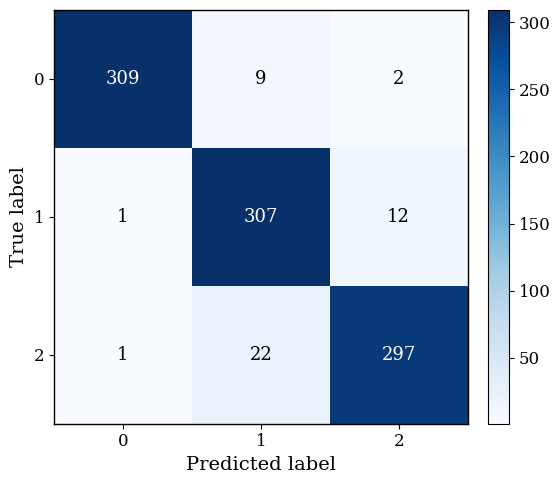

In [67]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# SCI-style global settings
# =========================
# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = ["DejaVu Serif"]
# plt.rcParams["font.size"] = 12
# plt.rcParams["axes.labelsize"] = 14
# plt.rcParams["axes.titlesize"] = 14
# plt.rcParams["xtick.labelsize"] = 12
# plt.rcParams["ytick.labelsize"] = 12
# plt.rcParams["pdf.fonttype"] = 42
# plt.rcParams["ps.fonttype"] = 42

# =========================
# Class names
# =========================
class_names = ["0", "1", "2"]

# 如果你的类别想用 0, 1, 2，也可以用：
# class_names = ["0", "1", "2"]

# =========================
# Plot confusion matrix
# =========================
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm, cmap="Blues")

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=12)

# Axis labels
ax.set_xlabel("Predicted label", fontsize=14)
ax.set_ylabel("True label", fontsize=14)

# Tick labels
ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))

ax.set_xticklabels(class_names, fontsize=12)
ax.set_yticklabels(class_names, fontsize=12)

# Rotate x-axis labels if needed
plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

# Write values in each cell
threshold = cm.max() / 2.0

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        value = cm[i, j]
        text_color = "white" if value > threshold else "black"
        ax.text(
            j, i, str(value),
            ha="center",
            va="center",
            color=text_color,
            fontsize=13
        )

# Remove unnecessary frame style adjustment
for spine in ax.spines.values():
    spine.set_linewidth(1.0)

# Layout
plt.tight_layout()

# =========================
# Save high-quality figures
# =========================
fig.savefig("confusion_matrix.png", dpi=600, bbox_inches="tight")
fig.savefig("confusion_matrix.pdf", bbox_inches="tight")
fig.savefig("confusion_matrix.tiff", dpi=600, bbox_inches="tight")

plt.show()